In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/19
    print("準備完了！このまま下のセルを実行できます。")


# 第19章 自己符号化器 (Autoencoders)
## 19.1 決定論的自己符号化器 (Deterministic Autoencoders)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第19章「自己符号化器」第1節「決定論的自己符号化器 (Deterministic Autoencoders)」の理論的背景、数式厳密導出、および完全なPython実装を提供します。

---

### 概要とモチベーション：内部表現の獲得と制約の導入

深層学習の中心的な目標の一つは、後続のタスク（分類、検索、生成など）にとって有用なデータの**内部表現 (Internal Representation)** を教師なしで発見することです。
その代表的な手法が**自己結合型ニューラルネットワーク (Auto-associative neural network)** または**自己符号化器 (Autoencoder)** です。

自己符号化器は、入力 $\mathbf{x} \in \mathbb{R}^D$ と同じ次元の出力 $\mathbf{y} \in \mathbb{R}^D$ を持ち、出力を入力に近づける（$\mathbf{y} \approx \mathbf{x}$）ように学習されます。
ネットワークは概念的に2つの部分に分解されます：
1. **符号化器 (Encoder) $F_1(\mathbf{x})$**: 入力 $\mathbf{x}$ を低次元またはスパースな潜在表現 $\mathbf{z}(\mathbf{x})$ に写像
2. **復号化器 (Decoder) $F_2(\mathbf{z})$**: 潜在表現 $\mathbf{z}$ をデータ空間の出力 $\mathbf{y}(\mathbf{z})$ に復元

> **重要な制約の必要性**:
> 単に $\mathbf{y} = \mathbf{x}$ を再現するだけなら、ネットワークは恒等写像（入力をそのままコピー）を学習してしまうという自明な解（Trivial solution）に陥ります。
> 非自明で有用な内部構造を獲得させるためには、何らかの**制約 (Constraint)** を導入することが不可欠です：
> - **ボトルネック制約 (§19.1.1, §19.1.2)**: 潜在空間の次元数をデータ空間より小さく制限する ($M < D$)
> - **スパース性制約 (§19.1.3)**: 正則化項を用いてユニットの活性化を疎にする
> - **ノイズ除去制約 (§19.1.4)**: 入力にノイズや欠損を加え、それを復元させる
> - **パッチマスキング制約 (§19.1.5)**: 入力画像の大半（75〜80%）をマスクし、欠落部分を予測させる (MAE)


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートのパス解決
sys.path.append(os.path.abspath(".."))

from common.plot_utils import setup_style
from common.deterministic_autoencoders import (
    LinearAutoencoder,
    DeepAutoencoder,
    SparseAutoencoder,
    DenoisingAutoencoder,
    MaskedAutoencoderViT,
    generate_figure_19_1,
    generate_figure_19_2,
    generate_figure_19_3,
    generate_figure_19_4,
    generate_figure_19_5,
    generate_figure_19_6,
)

setup_style()
print("モジュールと可視化スタイルのロードが完了しました。")


モジュールと可視化スタイルのロードが完了しました。


---
## 19.1.1 線形自己符号化器 (Linear Autoencoders)

まず、入力 $D$ 次元、出力 $D$ 次元、中間層 $M$ 次元（ただし $M < D$）を持つ2層のパーセプトロンを考えます（**Figure 19.1**）。
入力自身を目標値とし、二乗和誤差（Sum-of-squares error）を最小化します：

$$\begin{aligned}
\mathbf{z} &= \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1 \in \mathbb{R}^M \\
\mathbf{y} &= \mathbf{W}_2 \mathbf{z} + \mathbf{b}_2 \in \mathbb{R}^D
\end{aligned}$$

誤差関数は式 (19.1) で与えられます：

$$E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \|\mathbf{y}(\mathbf{x}_n, \mathbf{w}) - \mathbf{x}_n\|^2 \quad (19.1)$$

### Bourlard & Kamp (1988) / Baldi & Hornik (1989) の定理
- 中間層の活性化関数が線形である場合、誤差関数 $E(\mathbf{w})$ は唯一の大域的最小解を持ち、その大域的最小値においてネットワークは**データの第 $M$ 主成分が張る部分空間（PCA 部分空間）への射影**を実行する。
- 驚くべきことに、**中間層にシグモイドや tanh などの非線形活性化関数を用いた場合でも、最小誤差解は依然として主成分部分空間への射影となる**（Bourlard and Kamp, 1988）。
- したがって、2層の自己符号化器を用いて非線形な次元削減を行うことには利点がなく、標準的な特異値分解 (SVD) による PCA の方が確実に厳密解を得られます。


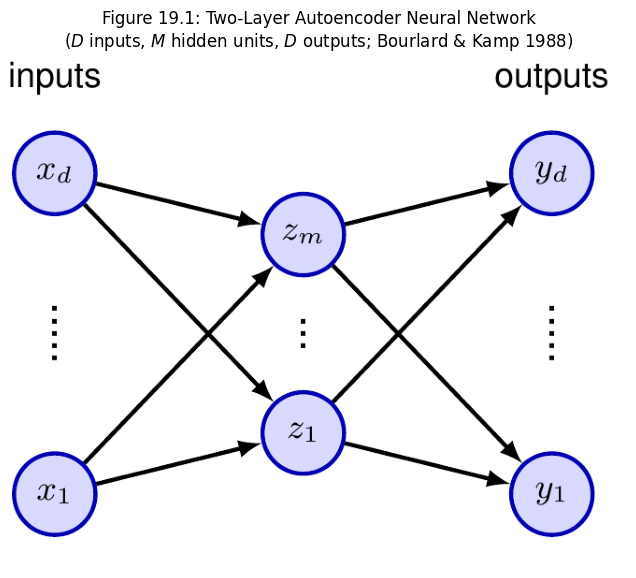

In [3]:
# Figure 19.1 の表示
fig19_1 = generate_figure_19_1()
plt.show()


[理論的 PCA] 理論的最小 MSE (切り捨てられた固有値の和): 3.5220
[線形自己符号化器] 学習後 MSE: 3.5220 (理論値との差: 0.0000)
[線形自己符号化器] PCA部分空間との射影行列距離 ||P_AE - P_PCA||_F: 0.0000


[tanh中間層自己符号化器] 学習後 MSE: 3.5970
[tanh中間層自己符号化器] PCA部分空間との射影行列距離 ||P_AE - P_PCA||_F: 0.0170


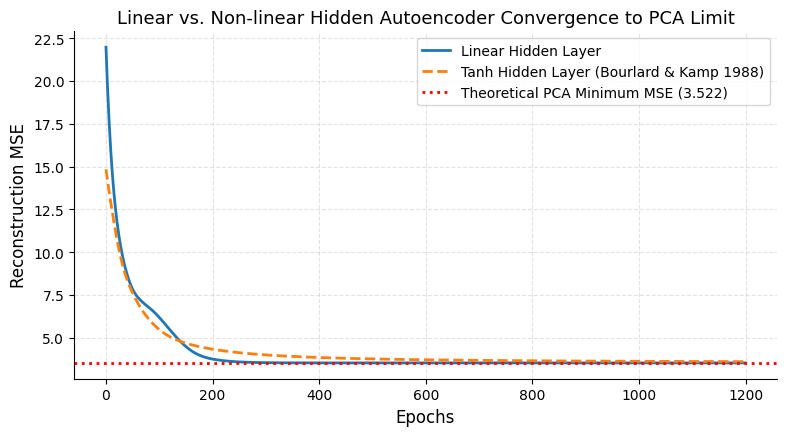

In [4]:
# === 19.1.1 実験: 線形自己符号化器の学習と PCA 部分空間への収束検証 ===
np.random.seed(42)
N, D, M = 500, 6, 2

# 相関のある多変量ガウス分布から合成データを生成
true_cov = np.diag([5.0, 3.5, 2.0, 1.0, 0.5, 0.2])
rot = np.linalg.qr(np.random.randn(D, D))[0]
cov = rot @ true_cov @ rot.T
x_data = np.random.multivariate_normal(mean=np.zeros(D), cov=cov, size=N)

# 1. 解析的 PCA の計算 (理論的最小復元誤差)
mean_pca, u_pca, theo_min_mse = LinearAutoencoder.compute_pca_baseline(x_data, latent_dim=M)
print(f"[理論的 PCA] 理論的最小 MSE (切り捨てられた固有値の和): {theo_min_mse:.4f}")

# 2. 線形自己符号化器 (Linear) の学習
ae_linear = LinearAutoencoder(input_dim=D, latent_dim=M, hidden_activation='linear', seed=42)
loss_history_linear = ae_linear.fit(x_data, n_epochs=1200, lr=0.01)
final_mse_linear = ae_linear.mean_squared_error(x_data)
dist_linear = ae_linear.subspace_distance(u_pca)
print(f"[線形自己符号化器] 学習後 MSE: {final_mse_linear:.4f} (理論値との差: {abs(final_mse_linear - theo_min_mse):.4f})")
print(f"[線形自己符号化器] PCA部分空間との射影行列距離 ||P_AE - P_PCA||_F: {dist_linear:.4f}")

# 3. 非線形中間層 (tanh) 自己符号化器の学習 (Bourlard & Kamp 定理の検証)
ae_tanh = LinearAutoencoder(input_dim=D, latent_dim=M, hidden_activation='tanh', seed=42)
loss_history_tanh = ae_tanh.fit(x_data, n_epochs=1200, lr=0.01)
final_mse_tanh = ae_tanh.mean_squared_error(x_data)
dist_tanh = ae_tanh.subspace_distance(u_pca)
print(f"[tanh中間層自己符号化器] 学習後 MSE: {final_mse_tanh:.4f}")
print(f"[tanh中間層自己符号化器] PCA部分空間との射影行列距離 ||P_AE - P_PCA||_F: {dist_tanh:.4f}")

# 学習曲線の可視化
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(loss_history_linear, label="Linear Hidden Layer", lw=2)
ax.plot(loss_history_tanh, label="Tanh Hidden Layer (Bourlard & Kamp 1988)", lw=2, linestyle="--")
ax.axhline(theo_min_mse, color="red", linestyle=":", lw=2, label=f"Theoretical PCA Minimum MSE ({theo_min_mse:.3f})")
ax.set_xlabel("Epochs")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("Linear vs. Non-linear Hidden Autoencoder Convergence to PCA Limit")
ax.legend()
plt.tight_layout()
plt.show()


---
## 19.1.2 深層自己符号化器 (Deep Autoencoders) と非線形 PCA

2層の自己符号化器では非線形活性化関数を用いても線形 PCA を超えられませんでしたが、**さらに追加の非線形隠れ層**を導入すると状況が一変します（**Figure 19.2**）。

### 4層自己結合ネットワークの幾何学的解釈 (Figure 19.3)
- ネットワークを2つの写像 $F_1$ と $F_2$ に分解：
  - **符号化器 $F_1: \mathbb{R}^D \to \mathbb{R}^M$**: 最初の非線形隠れ層により、データ空間から $M$ 次元の潜在空間への**一般的な非線形射影**を定義
  - **復号化器 $F_2: \mathbb{R}^M \to \mathbb{R}^D$**: $M$ 次元の潜在空間からデータ空間への**非線形な埋め込み**を定義
- $D=3, M=2$ の場合、復号化器 $F_2$ は3次元データ空間内に埋め込まれた**非平坦（曲面）な2次元多様体 $\mathcal{S}$** を表現できます（**Figure 19.3**）。
- これにより、線形 PCA では表現不可能な曲がった多様体上のデータを高精度に低次元圧縮・復元する**非線形 PCA (Nonlinear PCA)** が実現されます。


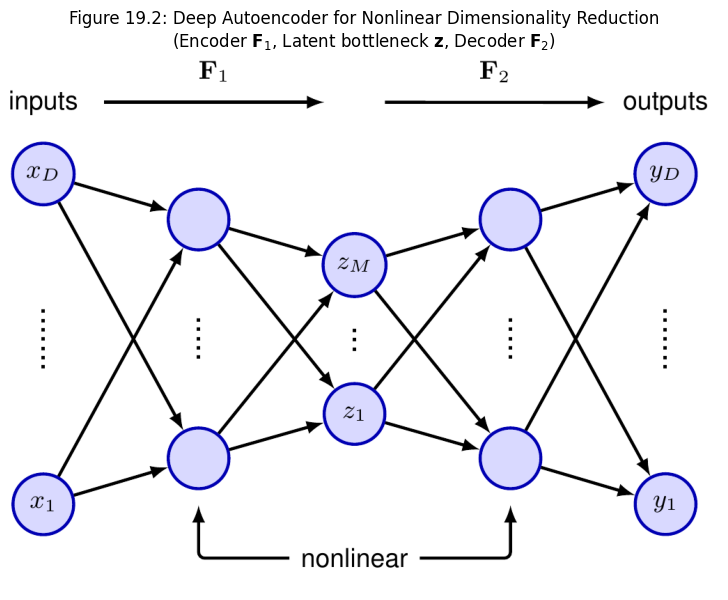

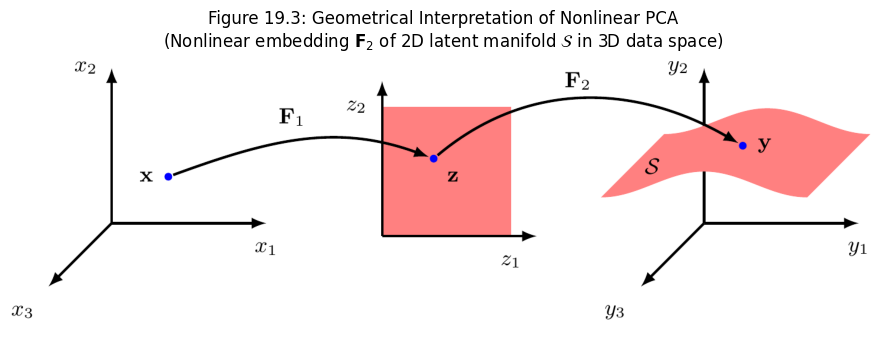

In [5]:
# Figure 19.2 および Figure 19.3 の表示
fig19_2 = generate_figure_19_2()
plt.show()

fig19_3 = generate_figure_19_3()
plt.show()


[線形 PCA (2成分)] 復元 MSE: 0.5925


[深層自己符号化器 (非線形PCA)] 復元 MSE: 0.0044
==> 深層AEによる誤差削減率: 99.3%


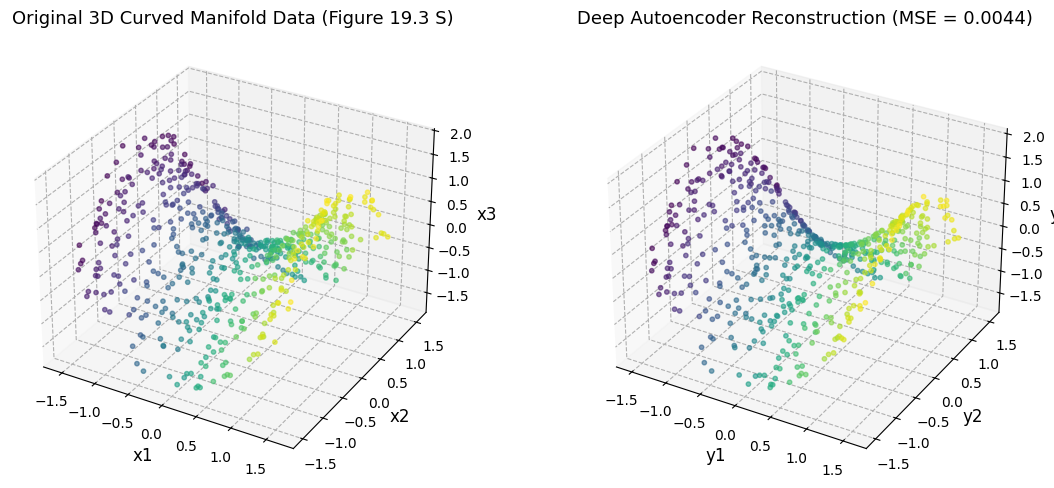

In [6]:
# === 19.1.2 実験: 曲面多様体上のデータにおける非線形 PCA と深層自己符号化器の比較 ===
np.random.seed(42)
N = 600

# 3次元空間内の曲がった2次元多様体 (サドル/波状曲面) データを生成 (Figure 19.3 の状況)
z1_true = np.random.uniform(-1.5, 1.5, N)
z2_true = np.random.uniform(-1.5, 1.5, N)
# 非線形埋め込み: y = [z1, z2, 0.8 * (z1^2 - z2^2)]
x3_true = 0.8 * (z1_true**2 - z2_true**2)
x_manifold = np.column_stack([z1_true, z2_true, x3_true]) + np.random.randn(N, 3) * 0.05

# 1. 線形 PCA ベースライン
_, _, pca_error = LinearAutoencoder.compute_pca_baseline(x_manifold, latent_dim=2)
print(f"[線形 PCA (2成分)] 復元 MSE: {pca_error:.4f}")

# 2. 深層自己符号化器 (3 -> 32 -> 2 -> 32 -> 3) の学習
deep_ae = DeepAutoencoder(layer_dims=[3, 32, 2, 32, 3], hidden_activation='tanh', seed=42)
deep_ae_loss = deep_ae.fit(x_manifold, n_epochs=1500, lr=0.008)
final_deep_error = deep_ae.mean_squared_error(x_manifold)
print(f"[深層自己符号化器 (非線形PCA)] 復元 MSE: {final_deep_error:.4f}")
print(f"==> 深層AEによる誤差削減率: {(1.0 - final_deep_error / pca_error) * 100:.1f}%")

# 3次元での復元結果の比較可視化
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x_manifold[:, 0], x_manifold[:, 1], x_manifold[:, 2], c=z1_true, cmap='viridis', s=10, alpha=0.6)
ax1.set_title("Original 3D Curved Manifold Data (Figure 19.3 S)")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("x3")

_, y_recon, _, _ = deep_ae.forward(x_manifold)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(y_recon[:, 0], y_recon[:, 1], y_recon[:, 2], c=z1_true, cmap='viridis', s=10, alpha=0.6)
ax2.set_title(f"Deep Autoencoder Reconstruction (MSE = {final_deep_error:.4f})")
ax2.set_xlabel("y1"); ax2.set_ylabel("y2"); ax2.set_zlabel("y3")
plt.tight_layout()
plt.show()


---
## 19.1.3 スパース自己符号化器 (Sparse Autoencoders)

内部表現を拘束する別のアプローチとして、隠れユニット数 $M$ を入力次元 $D$ より小さく制限する代わりに、**隠れユニットの活性化値に正則化項を加えてスパース（疎）な表現を促す**手法があります。

### $L_1$ 活性化正則化誤差関数 (Eq. 19.2)
スパース性を促す最も自然な選択は $L_1$ 正則化項であり、正則化された誤差関数は式 (19.2) で与えられます：

$$\widetilde{E}(\mathbf{w}) = E(\mathbf{w}) + \lambda \sum_{k=1}^K |z_k| \quad (19.2)$$

ここで、$E(\mathbf{w})$ は通常の復元二乗和誤差であり、第2項は指定した隠れ層の全ユニットの活性化値の絶対値の和です。
> **注意**:
> 通常の正則化（Weight Decay など）はネットワークの**重みパラメータ**に適用されますが、ここでは**ユニットの活性化値 $z_k$** に適用されている点が決定的に異なります。
> これにより、$M > D$ の過完備 (Overcomplete) なネットワークであっても恒等写像への自明な退化を防ぎ、局所的な特徴検出器（基底フィルタ）を獲得させることができます。


無正則化モデルの隠れ活性化絶対値平均: 0.4991
スパースモデル (lambda=0.2) の隠れ活性化絶対値平均: 0.1460
スパースモデルの不活性ニューロン比率 (|z| < 0.1): 55.6%


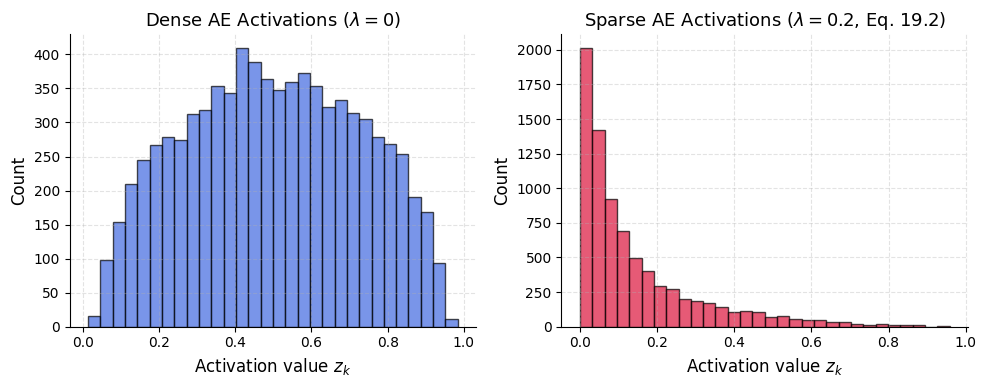

In [7]:
# === 19.1.3 実験: スパース自己符号化器の学習と活性化分布のスパース化検証 ===
np.random.seed(42)
N, D, M = 400, 8, 20  # 過完備 (Overcomplete: M=20 > D=8)

x_sparse_data = np.random.randn(N, D)

# 1. 無正則化自己符号化器 (lambda = 0.0)
sae_dense = SparseAutoencoder(input_dim=D, hidden_dim=M, l1_weight=0.0, activation='sigmoid', seed=42)
sae_dense.fit(x_sparse_data, n_epochs=500, lr=0.01)

# 2. スパース自己符号化器 (lambda = 0.2)
sae_sparse = SparseAutoencoder(input_dim=D, hidden_dim=M, l1_weight=0.2, activation='sigmoid', seed=42)
sae_sparse.fit(x_sparse_data, n_epochs=500, lr=0.01)

z_dense = sae_dense.encode(x_sparse_data)
z_sparse = sae_sparse.encode(x_sparse_data)

print(f"無正則化モデルの隠れ活性化絶対値平均: {np.mean(np.abs(z_dense)):.4f}")
print(f"スパースモデル (lambda=0.2) の隠れ活性化絶対値平均: {np.mean(np.abs(z_sparse)):.4f}")
print(f"スパースモデルの不活性ニューロン比率 (|z| < 0.1): {sae_sparse.sparsity_ratio(x_sparse_data, threshold=0.1) * 100:.1f}%")

# 活性化値のヒストグラム比較
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(z_dense.flatten(), bins=30, color='royalblue', alpha=0.7, edgecolor='black')
ax1.set_title("Dense AE Activations ($\lambda = 0$)")
ax1.set_xlabel("Activation value $z_k$"); ax1.set_ylabel("Count")

ax2.hist(z_sparse.flatten(), bins=30, color='crimson', alpha=0.7, edgecolor='black')
ax2.set_title("Sparse AE Activations ($\lambda = 0.2$, Eq. 19.2)")
ax2.set_xlabel("Activation value $z_k$"); ax2.set_ylabel("Count")
plt.tight_layout()
plt.show()


---
## 19.1.4 ノイズ除去自己符号化器 (Denoising Autoencoders) とスコアマッチング

自明な恒等写像を回避し、データの興味深い内部構造を発見させるもう1つの強力なアプローチが**ノイズ除去自己符号化器 (Denoising Autoencoder; Vincent et al., 2008)** です。

### 目的関数 (Eq. 19.3)
各入力ベクトル $\mathbf{x}_n$ にノイズを加えて汚損したベクトル $\widetilde{\mathbf{x}}_n$ を作成し、これを自己符号化器に入力して**元のノイズのないクリーンな入力 $\mathbf{x}_n$ を復元**するように学習します：

$$E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \|\mathbf{y}(\widetilde{\mathbf{x}}_n, \mathbf{w}) - \mathbf{x}_n\|^2 \quad (19.3)$$

ノイズの形態：
1. **ゼロマスキングノイズ**: 入力変数のランダムに選ばれた割合 $\nu \in [0, 1]$ を 0 に設定
2. **加法的ガウスノイズ**: 各入力変数に独立な平均 0、分散 $\sigma^2$ のガウスノイズ $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$ を加算

### スコアマッチングとの幾何学的関係 (Figure 19.4)
ノイズ除去自己符号化器の学習は、**スコアマッチング (Score Matching; Vincent, 2011)** と密接に関連しています。ここでスコアとは対数密度の勾配 $\mathbf{s}(\mathbf{x}) = \nabla_{\mathbf{x}} \ln p(\mathbf{x})$ です。
- 汚損されたデータ点 $\widetilde{\mathbf{x}}$ は、低次元多様体から離れた低密度領域に配置されます。
- 自己符号化器は汚損ベクトルを元に戻す写像を学習するため、変位ベクトル $\mathbf{y}(\widetilde{\mathbf{x}}) - \widetilde{\mathbf{x}}$ は**データ多様体（高密度領域）に向かうベクトル**となります（**Figure 19.4**）。
- したがって、学習された自己符号化器はデータ空間の任意の点においてスコア $\nabla_{\mathbf{x}} \ln p(\mathbf{x})$ の推定器として機能します。この原理は第20章の**拡散モデル (Diffusion Models)** の基礎となります。


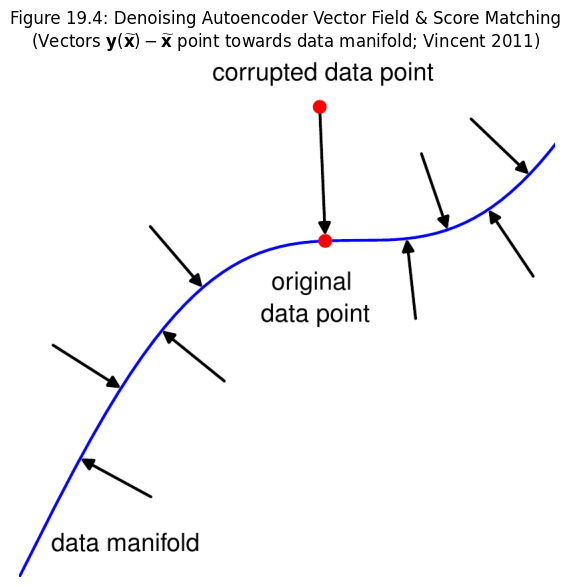

In [8]:
# Figure 19.4 の表示
fig19_4 = generate_figure_19_4()
plt.show()


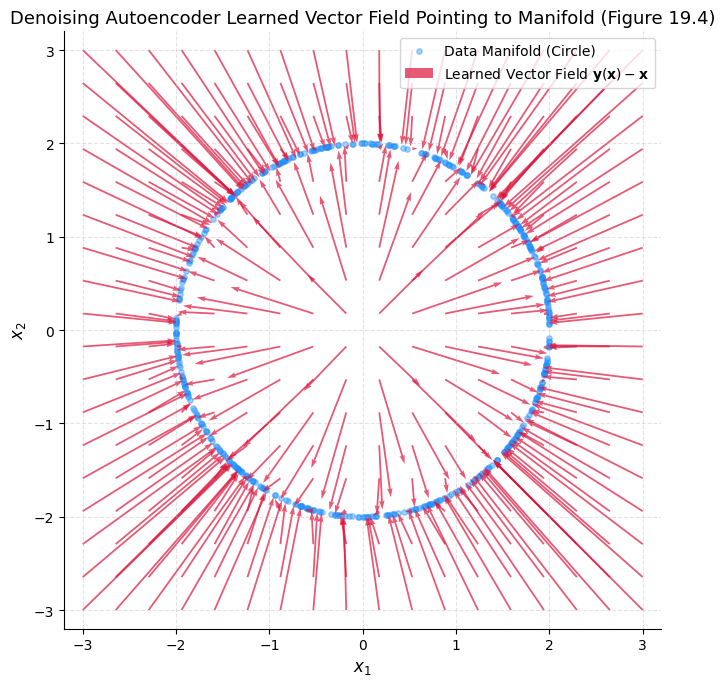

In [9]:
# === 19.1.4 実験: ノイズ除去自己符号化器の学習とベクトル場の可視化 (Figure 19.4 の再現) ===
np.random.seed(42)
N = 500

# 2次元空間内の円周多様体 (1D manifold embedded in 2D) データを生成
theta = np.random.uniform(0, 2 * np.pi, N)
r = 2.0
x_clean = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ノイズ除去自己符号化器の学習 (ガウスノイズ scale=0.3)
dae = DenoisingAutoencoder(layer_dims=[2, 32, 16, 32, 2], noise_type='gaussian', noise_scale=0.3, seed=42)
dae_loss = dae.fit(x_clean, n_epochs=1200, lr=0.01)

# グリッド上の点における変位ベクトル場 v(x) = y(x) - x を計算
grid_coords = np.linspace(-3.0, 3.0, 18)
gx, gy = np.meshgrid(grid_coords, grid_coords)
pts = np.column_stack([gx.flatten(), gy.flatten()])
disp = dae.vector_field(pts)

# クイーバープロット (ベクトル場) で多様体へ向かう様子を可視化
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x_clean[:, 0], x_clean[:, 1], color='dodgerblue', alpha=0.4, s=15, label="Data Manifold (Circle)")
ax.quiver(pts[:, 0], pts[:, 1], disp[:, 0], disp[:, 1], color='crimson', angles='xy', scale_units='xy', scale=1.0, width=0.003, alpha=0.7, label=r"Learned Vector Field $\mathbf{y}(\mathbf{x}) - \mathbf{x}$")
ax.set_title("Denoising Autoencoder Learned Vector Field Pointing to Manifold (Figure 19.4)")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


---
## 19.1.5 マスク自己符号化器 (Masked Autoencoders; MAE)

自然言語処理における BERT が入力単語のランダムマスキング（15%）による自己教師あり学習で豊かな内部表現を獲得したのと同様に、画像に対してもパッチのマスキングを用いた**マスク自己符号化器 (Masked Autoencoder; MAE, He et al., 2021)** が提案されました。

### アーキテクチャと非対称設計 (Figure 19.5)
1. **高比率マスキング (75〜80%)**:
   - 言語と異なり、自然画像は空間的冗長性が高く局所相関が極めて強いため、80% 程度の高いマスク比率が最も有効な内部表現をもたらします。
2. **非対称な Encoder-Decoder 構造**:
   - **Encoder (ViT)**: マスクされたパッチは入力せず、**可視パッチ (Visible patches, 20〜25%) のみ**を入力として処理します。これにより計算コストが劇的に削減されます。
   - **Decoder (軽量 ViT)**: Encoder 出力と学習可能な共通の `[mask_token]` を元の位置関係順に並べ戻し、位置エンコーディングを加算して復元を行います。
   - **損失関数**: 損失は**マスクされたパッチのみ**を対象として二乗平均誤差 (MSE) を計算します。
3. **高品質な画像復元 (Figure 19.6)**:
   - 学習完了後、Decoder は破棄され、Encoder は全画像をマスクなしで入力する下流タスク（分類や検出）の特徴抽出器として転移学習されます。


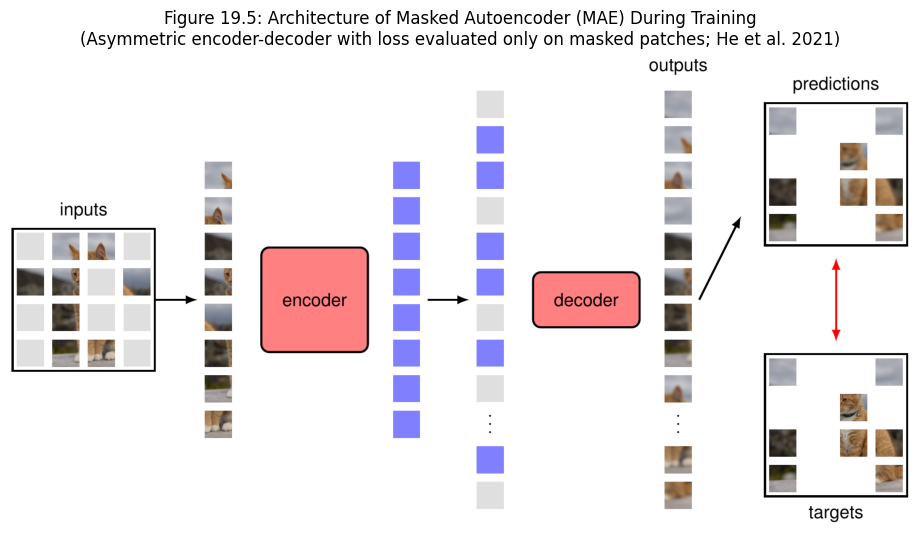

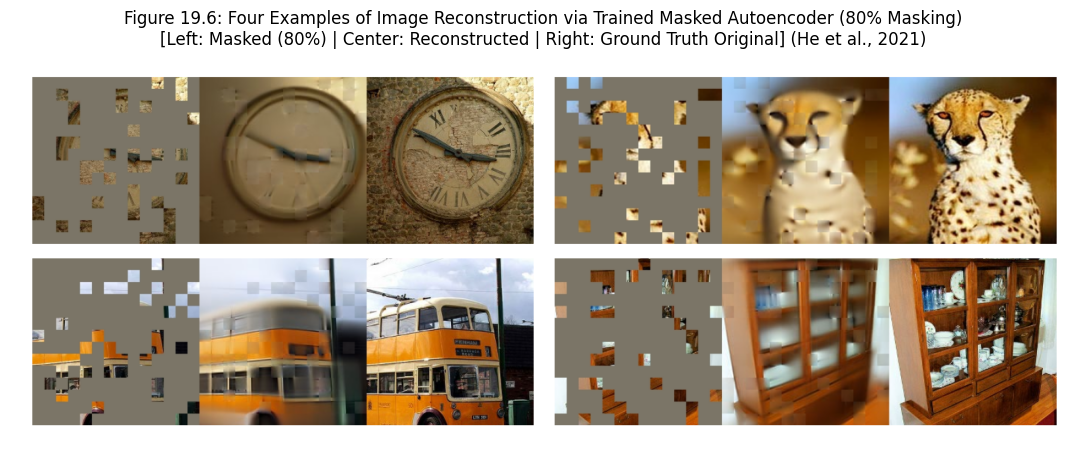

In [10]:
# Figure 19.5 および Figure 19.6 の表示
fig19_5 = generate_figure_19_5()
plt.show()

fig19_6 = generate_figure_19_6()
plt.show()


総パッチ数: 16
可視パッチ数 (Encoderに入力): 3
マスクされたパッチ数 (Decoderのみで復元): 13


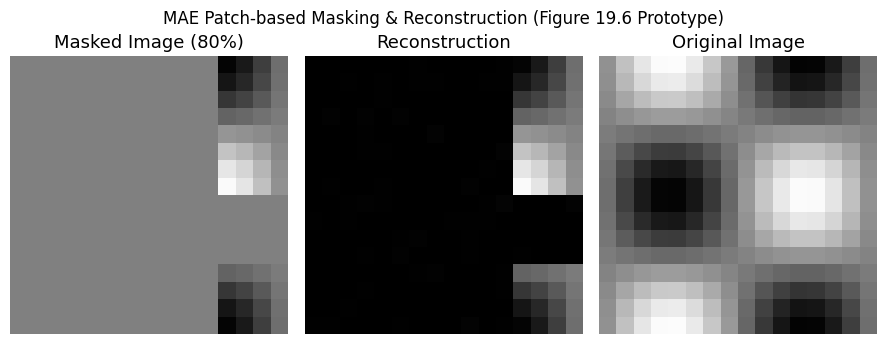

In [11]:
# === 19.1.5 実験: Masked Autoencoder (MAE) のパッチ化・マスキング・復元パイプライン ===
# 16x16 画像を 4x4 パッチ (全16パッチ) に分割し、80% マスク (可視3パッチ、マスク13パッチ)
mae = MaskedAutoencoderViT(img_size=16, patch_size=4, in_channels=1, mask_ratio=0.8, seed=42)

# テスト用画像 (幾何学的チェッカー・グラデーションパターン) を生成
grid = np.linspace(-1, 1, 16)
xx, yy = np.meshgrid(grid, grid)
sample_img = np.sin(3 * xx) * np.cos(3 * yy) * 0.5 + 0.5

# パッチ化とマスキングの確認
patches = mae.patchify(sample_img[np.newaxis, ..., np.newaxis])
x_vis, mask, ids_restore = mae.random_masking(patches, mask_ratio=0.8)

print(f"総パッチ数: {mae.num_patches}")
print(f"可視パッチ数 (Encoderに入力): {x_vis.shape[1]}")
print(f"マスクされたパッチ数 (Decoderのみで復元): {int(np.sum(mask))}")

# 画像の復元推論の実行
masked_v, recon_v, orig_v = mae.reconstruct_image(sample_img, mask_ratio=0.8)

# Figure 19.6 スタイルの 3連比較表示 (Masked | Reconstructed | Original)
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
axes[0].imshow(masked_v, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Masked Image (80%)")
axes[0].axis('off')

axes[1].imshow(recon_v, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Reconstruction")
axes[1].axis('off')

axes[2].imshow(orig_v, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("Original Image")
axes[2].axis('off')

plt.suptitle("MAE Patch-based Masking & Reconstruction (Figure 19.6 Prototype)", fontsize=12)
plt.tight_layout()
plt.show()


---
## まとめと次節への展望

本節では、決定論的自己符号化器（Deterministic Autoencoders）の理論と各種アーキテクチャを体系的に学びました：

1. **線形自己符号化器 (§19.1.1)**:
   - 2層の自己符号化器は、線形 PCA と厳密に等価な主成分部分空間への射影を学習する。
   - 非線形隠れ層を用いても主成分部分空間に収束する（Bourlard & Kamp 1988）。
2. **深層自己符号化器 (§19.1.2)**:
   - 複数の非線形層を積み重ねることで非線形 PCA を実現し、高次元空間内の非平坦な多様体 $\mathcal{S}$ を捉えることができる。
3. **スパース自己符号化器 (§19.1.3)**:
   - 活性化値への $L_1$ 正則化により、過完備な中間層であっても疎で有用な表現を獲得できる。
4. **ノイズ除去自己符号化器 (§19.1.4)**:
   - 入力汚損を元に戻す学習を通じて、データ多様体へ向かうベクトル場を獲得し、スコアマッチングと深く結びつく。
5. **マスク自己符号化器 (§19.1.5)**:
   - 画像パッチの 75〜80% をマスクし、可視パッチのみを処理する非対称 ViT により、計算効率と高品質な表現学習を両立する。

---

### 次節予告: 19.2 変分自己符号化器 (Variational Autoencoders; VAE)
決定論的自己符号化器は潜在空間の連続的な確率構造を定義しないため、潜在空間から新規サンプルを生成（サンプリング）することは困難です。
次節 **19.2 変分自己符号化器 (VAEs)** では、確率的エンコーダー $q(\mathbf{z}|\mathbf{x}, \boldsymbol{\phi})$ とデコーダー $p(\mathbf{x}|\mathbf{z}, \mathbf{w})$ を導入し、**変分下界 (ELBO)** の最大化と**再パラメータ化トリック (Reparameterization Trick)** を用いて深層生成モデルを構築します。
